Netflix----------------------------------------------------------------

1.Step 1 — Understand the Business Problem=========================================================

Step 2 — Data Understanding & Data Quality Audit==================================================================

In [341]:
import numpy as np
import pandas as pd

url='https://raw.githubusercontent.com/Gokulprasanth26/Netflix-Data-Analysis/refs/heads/main/netflix.csv'
df=pd.read_csv(url)
df.sample(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2348,s2349,Movie,The Royal Hibiscus Hotel,Ishaya Bako,"Zainab Balogun, Kenneth Okolie, Deyemi Okanlaw...",Nigeria,"June 22, 2020",2017,TV-PG,90 min,"Comedies, International Movies, Romantic Movies",A disenchanted chef tries to help her parents ...
1018,s1019,Movie,Jaane Tu... Ya Jaane Na,Abbas Tyrewala,"Imran Khan, Genelia D'Souza, Manjari Fadnis, A...",India,"April 17, 2021",2008,TV-14,147 min,"Comedies, International Movies, Music & Musicals",Soft-spoken Jai and spitfire beauty Aditi coul...
5672,s5673,TV Show,InuYasha,NaN,"Kappei Yamaguchi, Satsuki Yukino, Kumiko Watan...",Japan,"December 15, 2016",2001,TV-14,2 Seasons,"Anime Series, International TV Shows","Yanked down a well, schoolgirl Kagome Higurash..."
5884,s5885,Movie,John Mulaney: The Comeback Kid,Rhys Thomas,John Mulaney,United States,"November 13, 2015",2015,TV-MA,62 min,Stand-Up Comedy,"Armed with boyish charm and a sharp wit, the f..."
637,s638,TV Show,Ray,"Srijit Mukherji, Vasan Bala, Abhishek Chaubey","Manoj Bajpayee, Gajraj Rao, Kay Kay Menon, Ali...",NaN,"June 25, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries","From a satire to a psychological thriller, fou..."
4332,s4333,Movie,Battle,Katarina Launing,"Lisa Teige, Fabian Svegaard Tapia, Vebjørn Eng...","Norway, Denmark, Netherlands, Sweden","December 1, 2018",2018,TV-MA,98 min,"Dramas, International Movies, Romantic Movies","After Amalie's dad goes bankrupt, the young da..."
7630,s7631,Movie,Nymphomaniac: Volume 1,Lars von Trier,"Charlotte Gainsbourg, Stellan Skarsgård, Stacy...","Denmark, Germany, Belgium, United Kingdom, France","January 1, 2018",2013,NR,117 min,"Dramas, Independent Movies, International Movies",A self-diagnosed nymphomaniac reveals a lifeti...
856,s857,Movie,Strain,Uduak-Obong Patrick,"Okey Uzoeshi, Angel Unigwe, Nifemi Lawal, Alex...",NaN,"May 21, 2021",2020,TV-MA,107 min,"Dramas, International Movies",When his son is diagnosed with sickle cell dis...
1110,s1111,Movie,Madame Claude,Sylvie Verheyde,"Karole Rocher, Garance Marillier, Roschdy Zem,...",France,"April 2, 2021",2021,TV-MA,113 min,"Dramas, International Movies","In 1960s Paris, Madame Claude's influence exte..."
1664,s1665,Movie,Machete Kills,Robert Rodriguez,"Danny Trejo, Sofía Vergara, Charlie Sheen, Mic...","United States, Russia","November 22, 2020",2013,R,108 min,Action & Adventure,Killer-for-hire Machete cuts a deal with the U...


In [253]:
df.shape

(8807, 12)

In [340]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [255]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [256]:
df['title'].duplicated().sum()

0

In [257]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [258]:
df['rating'].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [259]:
df['release_year'].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

Step 3 —Data Cleaning ========================================================================

In [260]:
#filling the missing values in the director column with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['director'].head(10)

0                  Kirsten Johnson
1                          Unknown
2                  Julien Leclercq
3                          Unknown
4                          Unknown
5                    Mike Flanagan
6    Robert Cullen, José Luis Ucha
7                     Haile Gerima
8                  Andy Devonshire
9                   Theodore Melfi
Name: director, dtype: object

In [261]:
#Cleaning the whiespace in the director column
df['director'] = df['director'].str.strip()
df['director'].head(10)

0                  Kirsten Johnson
1                          Unknown
2                  Julien Leclercq
3                          Unknown
4                          Unknown
5                    Mike Flanagan
6    Robert Cullen, José Luis Ucha
7                     Haile Gerima
8                  Andy Devonshire
9                   Theodore Melfi
Name: director, dtype: object

In [262]:
#Doing the same for the cast column
df['cast'] = df['cast'].fillna('Unknown')
df['cast'] = df['cast'].str.strip()
df['cast'].head()

0                                              Unknown
1    Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2    Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                              Unknown
4    Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
Name: cast, dtype: object

In [263]:
#creating a duplicate of the data df as df_clean
df_clean=df.copy() 

df_clean['director'] = df_clean['director'].fillna('Unknown')
#fills na values into 'Unknown'
df_clean['director'] = df_clean['director'].str.strip()
#converts into a string as it is an object datatype
#" Kirsten Johnson " converts this to "Kirsten Johnson" when strip is used
df['director'].head(10)

0                  Kirsten Johnson
1                          Unknown
2                  Julien Leclercq
3                          Unknown
4                          Unknown
5                    Mike Flanagan
6    Robert Cullen, José Luis Ucha
7                     Haile Gerima
8                  Andy Devonshire
9                   Theodore Melfi
Name: director, dtype: object

In [264]:
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].str.strip()
df_clean['cast'].head(10)

0                                              Unknown
1    Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2    Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                              Unknown
4    Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
5    Kate Siegel, Zach Gilford, Hamish Linklater, H...
6    Vanessa Hudgens, Kimiko Glenn, James Marsden, ...
7    Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...
8    Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...
9    Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...
Name: cast, dtype: object

In [265]:
df_clean[['director','cast']].isna().sum()

director    0
cast        0
dtype: int64

In [266]:
#Check if all the missing values have been filled with "Unknown" in the director and cast columns
df_clean[['show_id', 'title', 'director', 'cast']].head(10)

,show_id,title,director,cast
0,s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown
1,s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
3,s4,Jailbirds New Orleans,Unknown,Unknown
4,s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K..."
5,s6,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H..."
6,s7,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ..."
7,s8,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D..."
8,s9,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho..."
9,s10,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T..."


Step 4 — Deep Cleaning & Transformation of director and cast=============================================================

In [267]:
#Splitting the director,cast column into an individual string list 
df_clean['director_list'] = df_clean['director'].str.split(',')
#"Robert Cullen, José Luis Ucha" converts to two string "Robert Cullen "," José Luis Ucha"
df_clean['cast_list'] = df_clean['cast'].str.split(',')
df_clean[['title','director','director_list','cast_list']].head(10)

,title,director,director_list,cast_list
0,Dick Johnson Is Dead,Kirsten Johnson,[Kirsten Johnson],[Unknown]
1,Blood & Water,Unknown,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th..."
2,Ganglands,Julien Leclercq,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, ..."
3,Jailbirds New Orleans,Unknown,[Unknown],[Unknown]
4,Kota Factory,Unknown,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Al..."
5,Midnight Mass,Mike Flanagan,[Mike Flanagan],"[Kate Siegel, Zach Gilford, Hamish Linklater..."
6,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","[Robert Cullen, José Luis Ucha]","[Vanessa Hudgens, Kimiko Glenn, James Marsde..."
7,Sankofa,Haile Gerima,[Haile Gerima],"[Kofi Ghanaba, Oyafunmike Ogunlano, Alexandr..."
8,The Great British Baking Show,Andy Devonshire,[Andy Devonshire],"[Mel Giedroyc, Sue Perkins, Mary Berry, Pau..."
9,The Starling,Theodore Melfi,[Theodore Melfi],"[Melissa McCarthy, Chris O'Dowd, Kevin Kline..."


In [268]:
#Cleans the spaces in the director_list and cast_list columns
df_clean['director_list'] = df_clean['director_list'].apply(lambda x:[name.strip() for name in x])
#"Robert Cullen "," José Luis Ucha" converts to "Robert Cullen","José Luis Ucha" uses for loop to check individual string her in this as Robert Cullen,José Luis Ucha
df_clean['cast_list'] = df_clean['cast_list'].apply(lambda x:[name.strip() for name in x])
df_clean[['title','director_list','cast_list']].head(10)

,title,director_list,cast_list
0,Dick Johnson Is Dead,[Kirsten Johnson],[Unknown]
1,Blood & Water,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba..."
2,Ganglands,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab..."
3,Jailbirds New Orleans,[Unknown],[Unknown]
4,Kota Factory,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ..."
5,Midnight Mass,[Mike Flanagan],"[Kate Siegel, Zach Gilford, Hamish Linklater, ..."
6,My Little Pony: A New Generation,"[Robert Cullen, José Luis Ucha]","[Vanessa Hudgens, Kimiko Glenn, James Marsden,..."
7,Sankofa,[Haile Gerima],"[Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra ..."
8,The Great British Baking Show,[Andy Devonshire],"[Mel Giedroyc, Sue Perkins, Mary Berry, Paul H..."
9,The Starling,[Theodore Melfi],"[Melissa McCarthy, Chris O'Dowd, Kevin Kline, ..."


In [269]:
title_cast = df_clean[['show_id', 'title', 'cast_list']].explode('cast_list')
#after seprating as each individual string we are exploding each individual string in each row
title_cast.head()

,show_id,title,cast_list
0,s1,Dick Johnson Is Dead,Unknown
1,s2,Blood & Water,Ama Qamata
1,s2,Blood & Water,Khosi Ngema
1,s2,Blood & Water,Gail Mabalane
1,s2,Blood & Water,Thabang Molaba


In [270]:
#title cast will be a relationship table for the main table df_clean
#the relationship table is created only for the column where there are list like values(here we have many cast members)
title_cast = title_cast.rename(columns={'cast_list':'cast_member'})
title_cast.head()

,show_id,title,cast_member
0,s1,Dick Johnson Is Dead,Unknown
1,s2,Blood & Water,Ama Qamata
1,s2,Blood & Water,Khosi Ngema
1,s2,Blood & Water,Gail Mabalane
1,s2,Blood & Water,Thabang Molaba


In [271]:
#relationship table for director
#title_director is created as there are many director for a single movie 
title_director = df_clean[['show_id','title','director_list']].explode('director_list')
title_director = title_director.rename(columns={'director_list':'director'})
title_director.head()

,show_id,title,director
0,s1,Dick Johnson Is Dead,Kirsten Johnson
1,s2,Blood & Water,Unknown
2,s3,Ganglands,Julien Leclercq
3,s4,Jailbirds New Orleans,Unknown
4,s5,Kota Factory,Unknown


In [272]:
title_director['director'].value_counts().head(10)

director
Unknown                2634
Rajiv Chilaka            22
Jan Suter                21
Raúl Campos              19
Suhas Kadav              16
Marcus Raboy             16
Jay Karas                15
Cathy Garcia-Molina      13
Martin Scorsese          12
Jay Chapman              12
Name: count, dtype: int64

In [273]:
title_cast['cast_member'].value_counts().head(10)

cast_member
Unknown             825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Name: count, dtype: int64

In [274]:
print(df_clean.shape)
print(title_director.shape)
print(title_cast.shape)

(8807, 14)
(9612, 3)
(64951, 3)


In [275]:
#We are filtering only the rows where the director is not 'Unknown',by preserving it instead of dropping it, we can use it for analysis later on. The same is done for the cast_member column.
title_director = title_director[title_director['director'] != 'Unknown']
title_cast = title_cast[title_cast['cast_member'] != 'Unknown']


In [276]:
print(df_clean.shape)
print(title_director.shape)
print(title_cast.shape)

(8807, 14)
(6978, 3)
(64126, 3)


In [277]:
#Checking for duplicates in the cast and director columns
title_cast.duplicated(subset=['show_id','cast_member']).sum()

2

In [278]:
title_cast[title_cast.duplicated(subset=['show_id','cast_member'],keep=False)]

,show_id,title,cast_member
1631,s1632,Rust Creek,Micah Hauptman
1631,s1632,Rust Creek,Micah Hauptman
6013,s6014,300 Miles to Heaven,Adrianna Biedrzyńska
6013,s6014,300 Miles to Heaven,Adrianna Biedrzyńska


In [279]:
title_director.duplicated(subset=['show_id','director']).sum()

1

In [280]:
title_director[title_director.duplicated(subset=['show_id','director'],keep=False)]

,show_id,title,director
3718,s3719,Blood Will Tell,Miguel Cohan
3718,s3719,Blood Will Tell,Miguel Cohan


In [281]:
#Check the main data for the duplicates
df_clean[df_clean['show_id']== 's3719'][['title','director']]


,title,director
3718,Blood Will Tell,"Miguel Cohan, Miguel Cohan"


In [282]:
#Dropping the duplicates in the cast and director columns
title_cast = title_cast.drop_duplicates(subset=['show_id','cast_member'])
title_director = title_director.drop_duplicates(subset=['show_id', 'director'])

title_cast.duplicated(subset=['show_id','cast_member']).sum()
title_director.duplicated(subset=['show_id','director']).sum()

0

Step 5 — Clean the Remaining Columns==========================================================================

In [283]:
df_clean['country'].isna().sum()

831

In [284]:
df_clean['country'].head(10)

0                                        United States
1                                         South Africa
2                                                  NaN
3                                                  NaN
4                                                India
5                                                  NaN
6                                                  NaN
7    United States, Ghana, Burkina Faso, United Kin...
8                                       United Kingdom
9                                        United States
Name: country, dtype: object

In [285]:
#Fill NaN/Null values to Unknown
df_clean['country'] = df_clean['country'].fillna('Unknown')  

#convert to list and split as an individual string
df_clean['country_list'] = df_clean['country'].str.split(',')

#strip removes the whitespace from the beginning and end of each string in the list 
df_clean['country_list'] = df_clean['country_list'].apply(lambda x: [country.strip() for country in x])

#explode the list into individual rows, creating a new row for each country associated with a title
title_country = df_clean[['show_id','title','country_list']].explode('country_list')

#rename the column to 'country'
title_country = title_country.rename(columns={'country_list':'country'})
#filter only the country named columns
title_country = title_country[title_country['country'] != 'Unknown']


title_country.head(15)


,show_id,title,country
0,s1,Dick Johnson Is Dead,United States
1,s2,Blood & Water,South Africa
4,s5,Kota Factory,India
7,s8,Sankofa,United States
7,s8,Sankofa,Ghana
7,s8,Sankofa,Burkina Faso
7,s8,Sankofa,United Kingdom
7,s8,Sankofa,Germany
7,s8,Sankofa,Ethiopia
8,s9,The Great British Baking Show,United Kingdom


In [286]:
df_clean.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,director_list,cast_list,country_list
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[Kirsten Johnson],[Unknown],[United States]


In [287]:
#Clean 'listed_in' column  
df_clean['listed_in'] = df_clean['listed_in'].fillna('Unknown')
df_clean['genre_list'] = df_clean['listed_in'].str.split(',')
df_clean['genre_list'] = df_clean['genre_list'].apply(lambda x: [genre.strip() for genre in x])

title_genre = df_clean[['show_id','title','genre_list']].explode('genre_list')
title_genre.rename(columns={'genre_list':'genre'},inplace=True)
title_genre.head(10)

,show_id,title,genre
0,s1,Dick Johnson Is Dead,Documentaries
1,s2,Blood & Water,International TV Shows
1,s2,Blood & Water,TV Dramas
1,s2,Blood & Water,TV Mysteries
2,s3,Ganglands,Crime TV Shows
2,s3,Ganglands,International TV Shows
2,s3,Ganglands,TV Action & Adventure
3,s4,Jailbirds New Orleans,Docuseries
3,s4,Jailbirds New Orleans,Reality TV
4,s5,Kota Factory,International TV Shows


In [288]:
#clean 'date_added' column
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,director_list,cast_list,country_list,genre_list
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[Kirsten Johnson],[Unknown],[United States],[Documentaries]
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],"[International TV Shows, TV Dramas, TV Mysteries]"
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],"[Crime TV Shows, International TV Shows, TV Ac..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",[Unknown],[Unknown],[Unknown],"[Docuseries, Reality TV]"
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],"[International TV Shows, Romantic TV Shows, TV..."


In [289]:
#clean 'date_added' column
df_clean['date_added'].dtype

dtype('O')

In [290]:
df_clean['date_added'] = df_clean['date_added'].fillna('Unknown')
#error shows 'NaT' Not a Time when "errors='coerce'" is used, if "errors='coerce'" not used then it fails
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), errors='coerce')

In [291]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   object        
 2   title          8807 non-null   object        
 3   director       8807 non-null   object        
 4   cast           8807 non-null   object        
 5   country        8807 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8803 non-null   object        
 9   duration       8804 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  director_list  8807 non-null   object        
 13  cast_list      8807 non-null   object        
 14  country_list   8807 non-null   object        
 15  genre_list     8807 n

In [292]:
df_clean['date_added'].head(10)

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
5   2021-09-24
6   2021-09-24
7   2021-09-24
8   2021-09-24
9   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [293]:
df_clean['added_year'] = df_clean['date_added'].dt.year
df_clean['added_month'] = df_clean['date_added'].dt.month 
df_clean['added_month_name'] = df_clean['date_added'].dt.month_name()

In [294]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,director_list,cast_list,country_list,genre_list,added_year,added_month,added_month_name
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[Kirsten Johnson],[Unknown],[United States],[Documentaries],2021.0,9.0,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,9.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],"[Crime TV Shows, International TV Shows, TV Ac...",2021.0,9.0,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",[Unknown],[Unknown],[Unknown],"[Docuseries, Reality TV]",2021.0,9.0,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],"[International TV Shows, Romantic TV Shows, TV...",2021.0,9.0,September


In [295]:
#clean 'duration' column
df_clean['movie_duration_min'] = np.where(
    df_clean['type'] == 'Movie',
    df_clean['duration'].str.extract(r'(\d+)')[0].astype(float),
    np.nan
)

df_clean['tv_seasons'] = np.where(
    df_clean['type'] == 'TV Show',
    df_clean['duration'].str.extract(r'(\d+)')[0].astype(float),
    np.nan
)

In [296]:
#clean rating column
df_clean['rating'] = df['rating'].fillna('Unknown')

In [297]:
df_clean.isna().sum()

show_id                  0
type                     0
title                    0
director                 0
cast                     0
country                  0
date_added              10
release_year             0
rating                   0
duration                 3
listed_in                0
description              0
director_list            0
cast_list                0
country_list             0
genre_list               0
added_year              10
added_month             10
added_month_name        10
movie_duration_min    2679
tv_seasons            6131
dtype: int64

In [298]:
print(df_clean.shape)
print(title_cast.shape)
print(title_director.shape)
print(title_country.shape)
print(title_genre.shape)

(8807, 21)
(64124, 3)
(6977, 3)
(10019, 3)
(19323, 3)


Step 6 — Exploratory Data Analysis (Validation EDA)============================================================

In [299]:
df_clean.shape

(8807, 21)

In [300]:
df_clean['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Content distribution-------------------------------

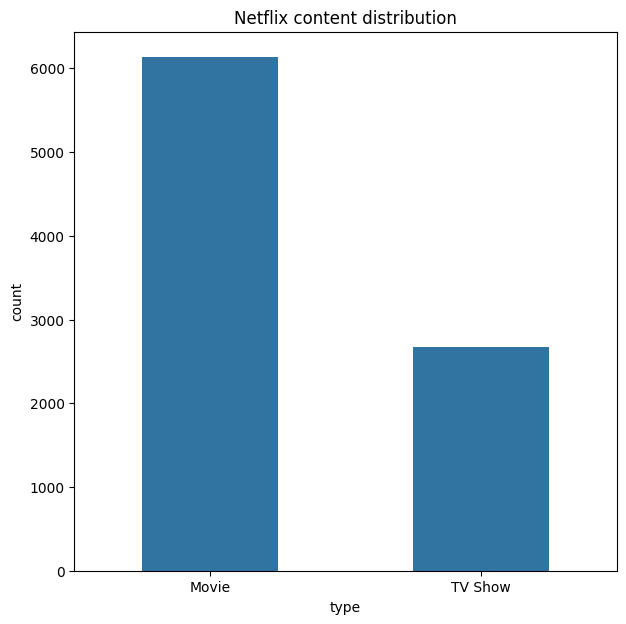

In [301]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,7))

sns.countplot(data=df_clean,x='type',width=0.5)

plt.title('Netflix content distribution')
plt.show()

#Netflix has more movies compared to TV Shows

In [302]:
content_percentage = (df_clean['type'].value_counts(normalize=True)*100)
content_percentage.round(2)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

Title added to Netflix for each year-------------------------------------

In [303]:
df_clean.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,director_list,cast_list,country_list,genre_list,added_year,added_month,added_month_name,movie_duration_min,tv_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",[Kirsten Johnson],[Unknown],[United States],[Documentaries],2021.0,9.0,September,90.0,NaN


added_year
2019.0    2016
2020.0    1879
2018.0    1649
2021.0    1498
2017.0    1188
2016.0     429
2015.0      82
2014.0      24
2011.0      13
2013.0      11
2012.0       3
2009.0       2
2008.0       2
2010.0       1
Name: count, dtype: int64


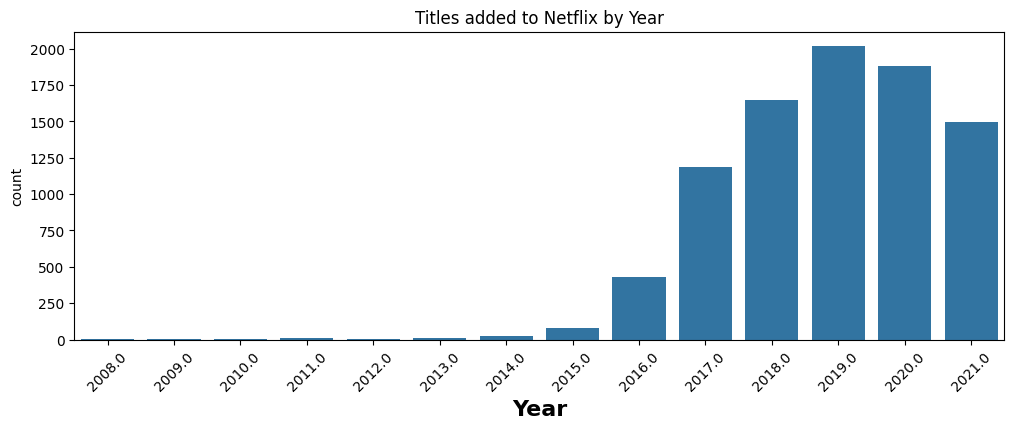

In [304]:
print(df_clean['added_year'].value_counts())

plt.figure(figsize=(12,4))
sns.countplot(data=df_clean,x='added_year',order=sorted(df_clean['added_year'].dropna().unique()))
#dropna().unique() --> these removes the NaN from the xlabel

plt.title('Titles added to Netflix by Year')
plt.xticks(rotation=45)
plt.xlabel('Year',fontdict={'fontsize':16,'fontweight':'bold'})
plt.show()


type        Movie  TV Show
added_year                
2008.0          1        1
2009.0          2        0
2010.0          1        0
2011.0         13        0
2012.0          3        0
2013.0          6        5
2014.0         19        5
2015.0         56       26
2016.0        253      176
2017.0        839      349
2018.0       1237      412
2019.0       1424      592
2020.0       1284      595
2021.0        993      505


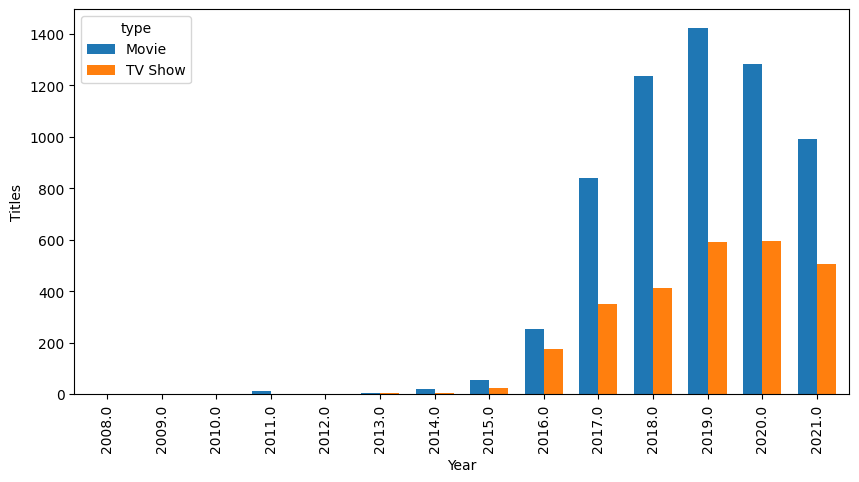

In [305]:
#cross tab counts the values of the row and column(like countplot in seaborn we give x and y columns it counts)
#we can also do by adding hue in seaborn chart used above
#sns.countplot(data=df_clean,x='added_year',hue='type')
content_growth=pd.crosstab(df_clean['added_year'],df_clean['type'])
#crosstab is used for two categorical variables for single categorical variable we use value_counts()
#Not to be used for Numerical variable
print(content_growth)

content_growth.plot(kind='bar',figsize=(10,5),width=0.7)

plt.xlabel('Year')
plt.ylabel('Titles')
plt.show()

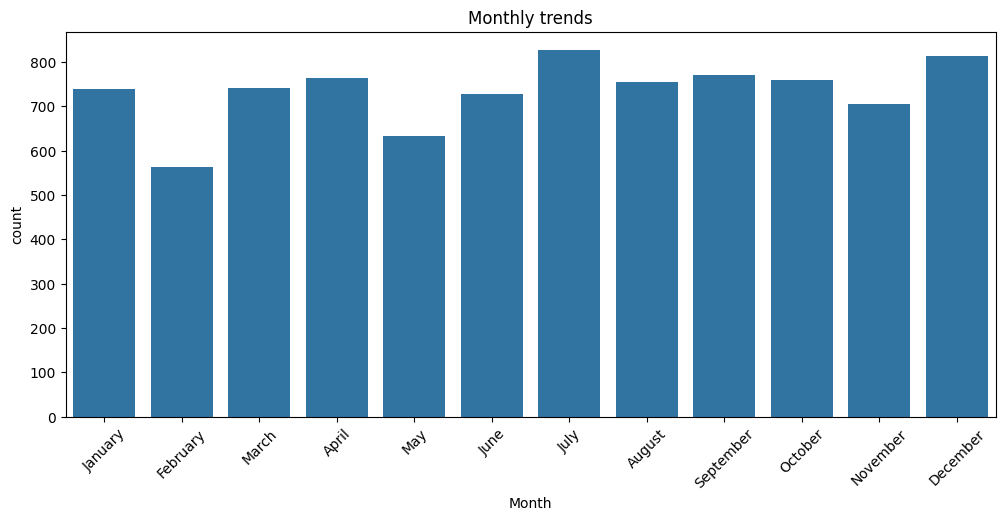

In [306]:
x=['January','February','March','April','May','June','July','August','September','October','November','December']

plt.figure(figsize=(12,5))
sns.countplot(data=df_clean,x='added_month_name',order=x)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Monthly trends')
plt.show()

Step 7 — Geographic Analysis (Country Analysis)==============================================================

Which countries contribute the most Netflix titles?--------------------------------------------------

In [307]:
title_country.head(2)

,show_id,title,country
0,s1,Dick Johnson Is Dead,United States
1,s2,Blood & Water,South Africa


In [308]:
country_count = title_country['country'].value_counts(ascending=False)
country_count.head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

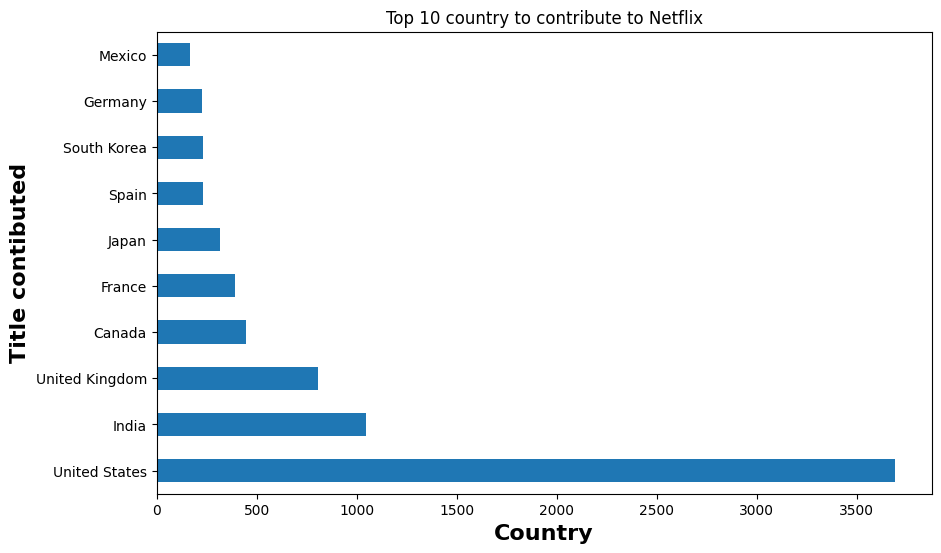

In [309]:
plt.figure(figsize=(10,6))


country_count.head(10).plot(kind='barh')

plt.title('Top 10 country to contribute to Netflix')
plt.xlabel('Country',fontdict={'fontsize':16,'fontweight':'bold'})
plt.ylabel('Title contibuted',fontdict={'fontsize':16,'fontweight':'bold'})
plt.show()

Movies vs TV Shows by Country--------------------------------------------

In [310]:
title_country.head()
df_clean.head()

#To fetch country we use title_country(the untangeld version of country done previously till explosion) and merge
country_type = title_country.merge(df_clean[['show_id','type']],on='show_id',how='left').head(10)
country_type.head()

,show_id,title,country,type
0,s1,Dick Johnson Is Dead,United States,Movie
1,s2,Blood & Water,South Africa,TV Show
2,s5,Kota Factory,India,TV Show
3,s8,Sankofa,United States,Movie
4,s8,Sankofa,Ghana,Movie


In [311]:
#As country and type are both "Categorical" data we use crosstab so we can have an idea on the variables before visualization
country_type_table = pd.crosstab(country_type['country'],country_type['type'])
country_type_table.index.name = None
country_type_table.columns.name = None
country_type_table.head(10)
#the first one in the table is blank as it represents NaN

,Movie,TV Show
Burkina Faso,1,0
Ethiopia,1,0
Germany,1,0
Ghana,1,0
India,0,1
South Africa,0,1
United Kingdom,1,1
United States,2,0


In [312]:
top10 = country_count.head(10).index

country_type_table.loc[top10].plot(kind='bar',figsize=(12,6))

plt.ylabel("Title")
plt.title("Movies vs TV Shows in top 10 Countries")
plt.show()

KeyError: "['Canada', 'France', 'Japan', 'Spain', 'South Korea', 'Mexico'] not in index"

Country diversity----------------------

In [ ]:
country_percentage = title_country['country'].value_counts(normalize=True)*100
country_percentage.head(10)

country
United States     36.830023
India             10.440164
United Kingdom     8.044715
Canada             4.441561
France             3.922547
Japan              3.173969
Spain              2.315600
South Korea        2.305619
Germany            2.255714
Mexico             1.686795
Name: proportion, dtype: float64

Which countries have diversified content?---------------------------------------------

In [ ]:
diversed_content = country_type.groupby('country')['type'].nunique()
diversed_content[diversed_content==2]

country
                        2
Argentina               2
Australia               2
Austria                 2
Belgium                 2
                       ..
United Arab Emirates    2
United Kingdom          2
United States           2
Uruguay                 2
West Germany            2
Name: type, Length: 61, dtype: int64

How many titles were added each year from each country? ----------------------------

In [ ]:
country_type = title_country.merge(df_clean[['show_id','added_year']],on='show_id')
country_type.head()

,show_id,title,country,added_year
0,s1,Dick Johnson Is Dead,United States,2021.0
1,s2,Blood & Water,South Africa,2021.0
2,s5,Kota Factory,India,2021.0
3,s8,Sankofa,United States,2021.0
4,s8,Sankofa,Ghana,2021.0


<Figure size 2400x1200 with 0 Axes>

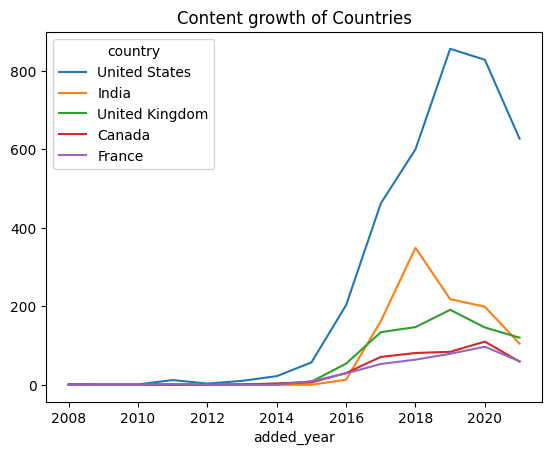

In [ ]:
country_year = pd.crosstab(country_type['added_year'],country_type['country'])

top5=country_count.head(5).index

plt.figure(figsize=(12,6),dpi=200)

country_year[top5].plot()
plt.title('Content growth of Countries')
plt.show()

In [ ]:
country_release = title_country.merge(df_clean[['show_id','release_year']],on='show_id')
country_release.head()

,show_id,title,country,release_year
0,s1,Dick Johnson Is Dead,United States,2020
1,s2,Blood & Water,South Africa,2021
2,s5,Kota Factory,India,2021
3,s8,Sankofa,United States,1993
4,s8,Sankofa,Ghana,1993


In [ ]:
country_release.groupby(['country'])['release_year'].mean().head(10)

country
               2011.428571
Afghanistan    2016.000000
Albania        2018.000000
Algeria        2004.333333
Angola         2020.000000
Argentina      2015.780220
Armenia        2017.000000
Australia      2014.162500
Austria        2017.750000
Azerbaijan     2013.000000
Name: release_year, dtype: float64

Top Countries by Recent Additions------------------------------------

In [ ]:
country_type[country_type['added_year'] >2020].value_counts().head(10)

show_id  title                                        country        added_year
s1       Dick Johnson Is Dead                         United States  2021.0        1
s56      Nailed It                                    United States  2021.0        1
s567     Charlie's Angels                             Germany        2021.0        1
s566     Bureau of Magical Things                     Germany        2021.0        1
                                                      Australia      2021.0        1
s565     Boogie Nights                                United States  2021.0        1
s564     Austin Powers: The Spy Who Shagged Me        United States  2021.0        1
s563     Austin Powers: International Man of Mystery  United States  2021.0        1
s562     Austin Powers in Goldmember                  United States  2021.0        1
s560     Air Force One                                United States  2021.0        1
Name: count, dtype: int64

Step 8 — Genre Analysis=====================================================================

In [ ]:
title_genre.head()

,show_id,title,genre
0,s1,Dick Johnson Is Dead,Documentaries
1,s2,Blood & Water,International TV Shows
1,s2,Blood & Water,TV Dramas
1,s2,Blood & Water,TV Mysteries
2,s3,Ganglands,Crime TV Shows


genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


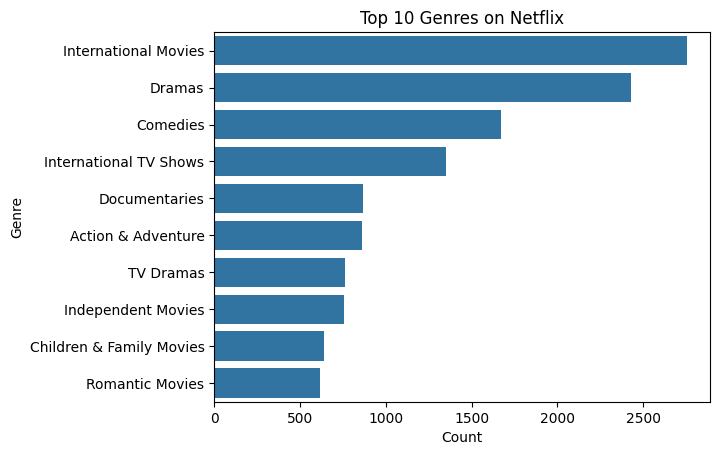

In [ ]:
genre_count = title_genre['genre'].value_counts(ascending =False).head(10)

print(genre_count)

sns.barplot(x=genre_count.values,y=genre_count.index)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

Difference in Genre with Movies VS TV Show------------------------------------------

In [ ]:
df_clean.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,director_list,cast_list,country_list,genre_list,added_year,added_month,added_month_name,movie_duration_min,tv_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",[Kirsten Johnson],[Unknown],[United States],[Documentaries],2021.0,9.0,September,90.0,NaN


In [ ]:
genre_type = title_genre.merge(df_clean[['show_id','type']],on='show_id',how='left')
genre_type.head()

,show_id,title,genre,type
0,s1,Dick Johnson Is Dead,Documentaries,Movie
1,s2,Blood & Water,International TV Shows,TV Show
2,s2,Blood & Water,TV Dramas,TV Show
3,s2,Blood & Water,TV Mysteries,TV Show
4,s3,Ganglands,Crime TV Shows,TV Show


In [ ]:
genre_type_table = pd.crosstab(genre_type['genre'],genre_type['type'])
genre_type_table.head()

type,Movie,TV Show
genre,,
Action & Adventure,859,0
Anime Features,71,0
Anime Series,0,176
British TV Shows,0,253
Children & Family Movies,641,0


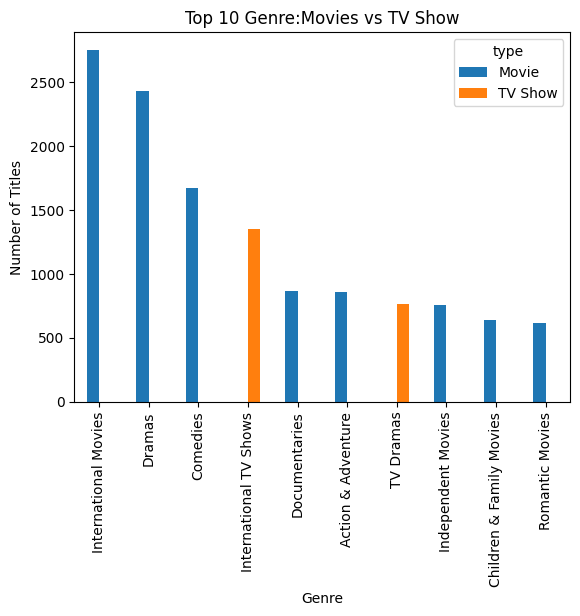

In [ ]:
top_genres = genre_count.index

genre_type_table.loc[top_genres].plot(kind='bar')

plt.title('Top 10 Genre:Movies vs TV Show')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.show()

Which genres are particularly strong for Movies?--------------------------------------------

In [ ]:
#for movie
movie_genres = (genre_type[genre_type['type']=='Movie']['genre'].value_counts(ascending=False))
movie_genres.head()

#for Tv_show
tv_genres = genre_type[genre_type['type']=='TV Show']['genre'].value_counts(ascending=False)
tv_genres.head()

genre
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Name: count, dtype: int64

In [ ]:
movie_genres.head()

genre
International Movies    2752
Dramas                  2427
Comedies                1674
Documentaries            869
Action & Adventure       859
Name: count, dtype: int64

Text(0, 0.5, 'Genre')

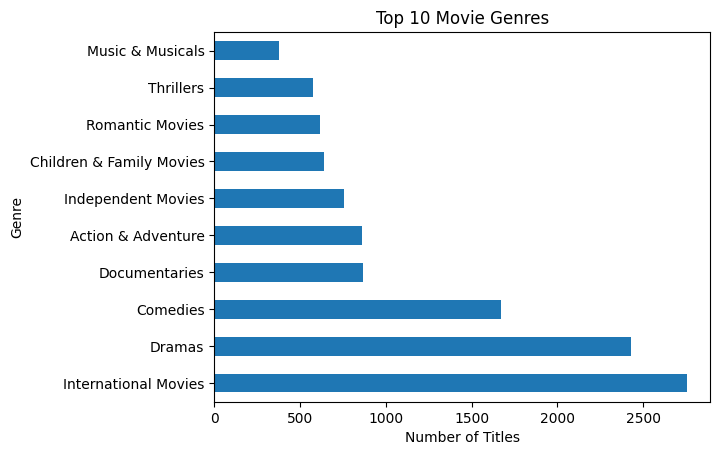

In [ ]:
movie_genres.head(10).plot(kind='barh')

plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

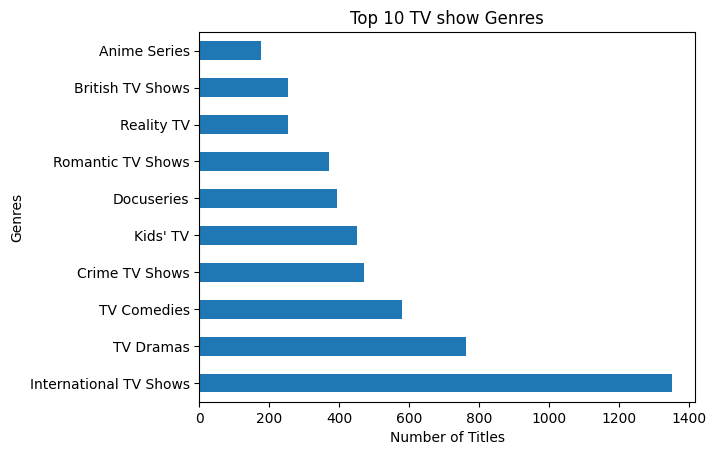

In [ ]:
tv_genres.head(10).plot(kind='barh')

plt.title('Top 10 TV show Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genres')
plt.show()

What percentage of Movies belong to each genre?------------------------------------------

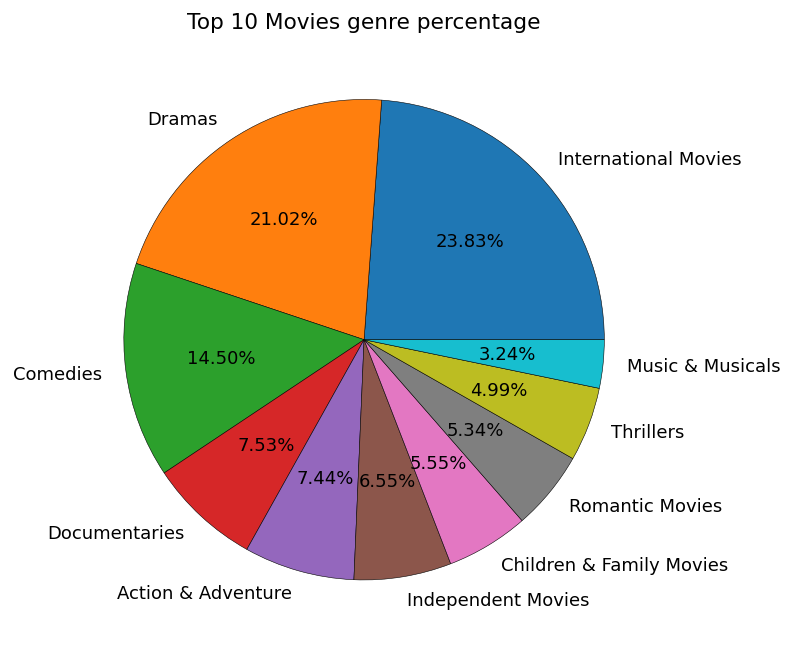

In [ ]:
movie_genre_percentage = round((movie_genres/movie_genres.sum())*100,2)
top10_movie_genre = movie_genre_percentage.head(10)

plt.figure(figsize=(12,6),dpi=130)
plt.pie(x=top10_movie_genre.values,labels=top10_movie_genre.index,autopct='%1.2f%%',wedgeprops={'edgecolor':'black','linewidth':0.3})
plt.title('Top 10 Movies genre percentage')
plt.show()

In [ ]:
tv_genre_percentage = round((tv_genres/tv_genres.sum())*100,2)
tv_genre_percentage.head(10)

genre
International TV Shows    22.03
TV Dramas                 12.44
TV Comedies                9.47
Crime TV Shows             7.66
Kids' TV                   7.35
Docuseries                 6.44
Romantic TV Shows          6.03
Reality TV                 4.16
British TV Shows           4.13
Anime Series               2.87
Name: count, dtype: float64

How many different genres exist for each type-------------------

In [ ]:
title_genre.head(2)

,show_id,title,genre
0,s1,Dick Johnson Is Dead,Documentaries
1,s2,Blood & Water,International TV Shows


In [ ]:
title_genre['genre'].nunique()

42

In [ ]:
genre_type.head(1)

genre_type.groupby('type')['genre'].nunique()

type
Movie      20
TV Show    22
Name: genre, dtype: int64

Genre growth over time--------------------------------------------------

In [ ]:
genre_year = title_genre.merge(df_clean[['show_id','added_year','added_month']],on='show_id',how='left')
genre_year.head()

,show_id,title,genre,added_year,added_month
0,s1,Dick Johnson Is Dead,Documentaries,2021.0,9.0
1,s2,Blood & Water,International TV Shows,2021.0,9.0
2,s2,Blood & Water,TV Dramas,2021.0,9.0
3,s2,Blood & Water,TV Mysteries,2021.0,9.0
4,s3,Ganglands,Crime TV Shows,2021.0,9.0


In [ ]:
top5_genres = (title_genre['genre'].value_counts().head(5).index)

genre_year_top5 = genre_year[genre_year['genre'].isin(top5_genres)]
genre_year_top5

genre_trend = pd.crosstab(genre_year_top5['added_year'],genre_year_top5['genre'])
genre_trend.head()


genre,Comedies,Documentaries,Dramas,International Movies,International TV Shows
added_year,,,,,
2008.0,0,0,1,0,0
2009.0,0,0,1,1,0
2011.0,0,0,13,1,0
2012.0,2,1,0,0,0
2013.0,1,1,0,0,1


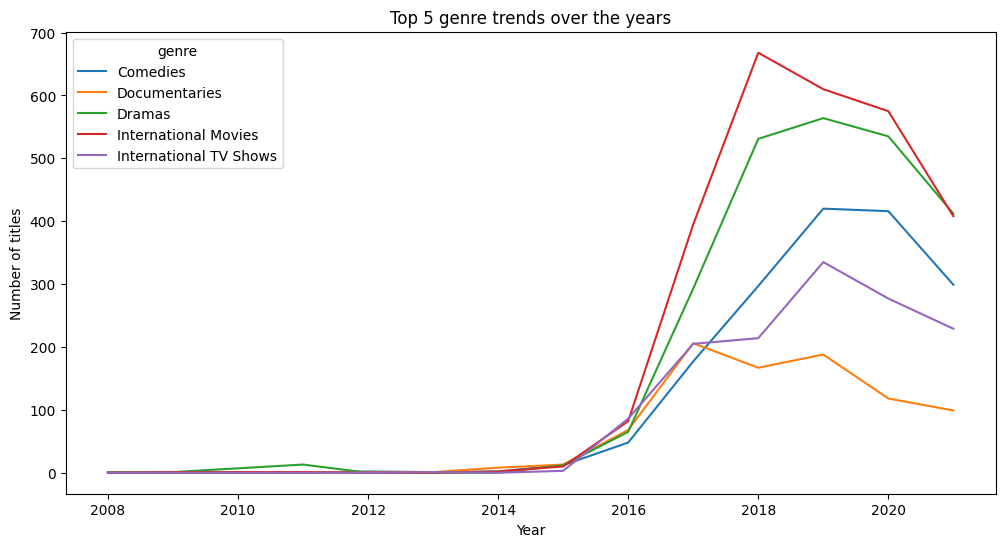

In [ ]:
genre_trend.plot(kind='line',figsize=(12,6))
plt.title('Top 5 genre trends over the years')
plt.xlabel('Year')
plt.ylabel('Number of titles')
plt.show()

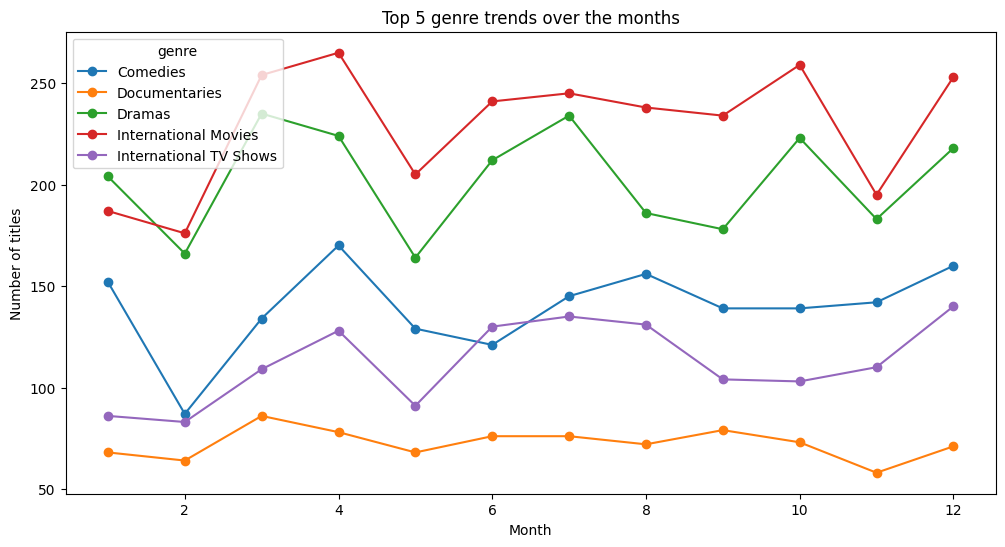

In [ ]:
top5_genres = (title_genre['genre'].value_counts().head(5).index)
top5_genres

genre_month_top5 = genre_year[genre_year['genre'].isin(top5_genres)]
genre_month_top5

genre_trend = pd.crosstab(genre_month_top5['added_month'],genre_month_top5['genre'])
genre_trend.head()

genre_trend.plot(kind='line',figsize=(12,6),marker='o')
plt.title('Top 5 genre trends over the months')
plt.xlabel('Month')
plt.ylabel('Number of titles')
plt.show()

In [ ]:
title_genre.duplicated(
    subset=['show_id', 'genre']
).sum()

#no duplicated data is good

0

Observation:
Drama represents one of the largest genre categories in Netflix's catalog.

Interpretation:
This indicates that Netflix has maintained a substantial content portfolio in drama-related categories.

Business insight:
Netflix could evaluate whether the continued expansion of drama content aligns with viewing engagement and retention metrics before increasing investment further.

Step 9 — Ratings & Content Classification Analysis================================================================

In [ ]:
#We will use df_clean only for this step because rating and type are attributes of the title itself.
df_clean.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,director_list,cast_list,country_list,genre_list,added_year,added_month,added_month_name,movie_duration_min,tv_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",[Kirsten Johnson],[Unknown],[United States],[Documentaries],2021.0,9.0,September,90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,"After crossing paths at a party, a Cape Town t...",[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,9.0,September,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,To protect his family from a powerful drug lor...,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Unknown],"[Crime TV Shows, International TV Shows, TV Ac...",2021.0,9.0,September,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,...,"Feuds, flirtations and toilet talk go down amo...",[Unknown],[Unknown],[Unknown],"[Docuseries, Reality TV]",2021.0,9.0,September,NaN,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,In a city of coaching centers known to train I...,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],"[International TV Shows, Romantic TV Shows, TV...",2021.0,9.0,September,NaN,2.0


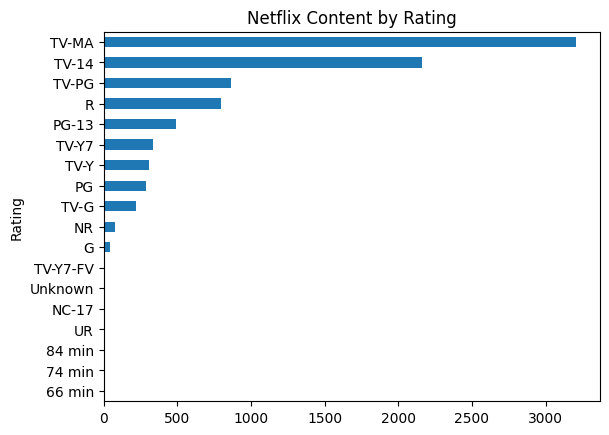

In [ ]:
rating_count = df_clean['rating'].value_counts(dropna=False)
rating_count.head()

rating_count.sort_values().plot(kind='barh')
plt.title('Netflix Content by Rating')
plt.ylabel('Rating')
plt.show()

How do ratings differ between Movies and TV Shows?----------------------------------------------

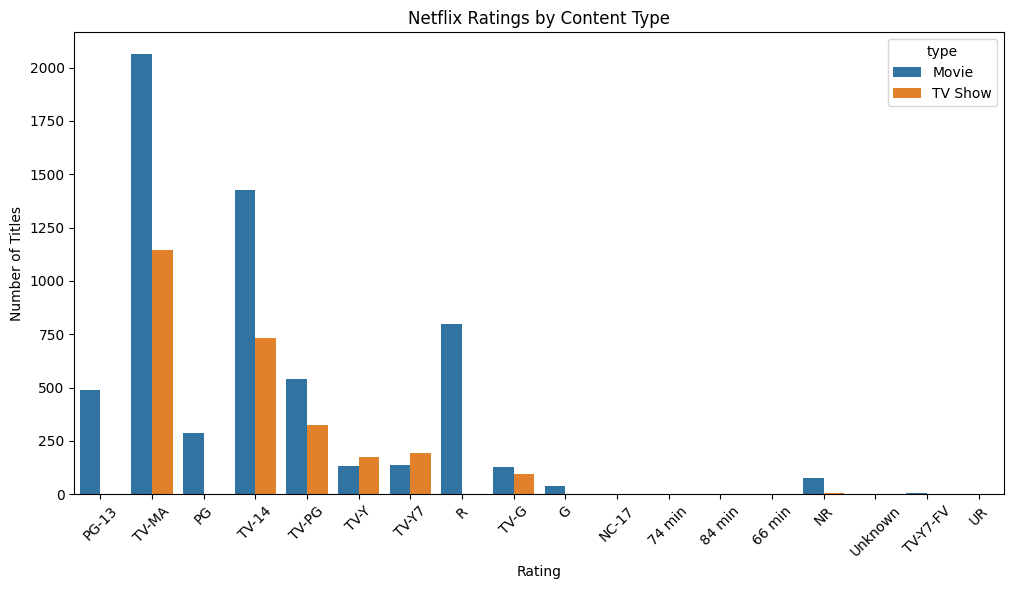

In [ ]:
rating_type = pd.crosstab(df_clean['rating'],df_clean['type'])
rating_type.head()

plt.figure(figsize=(12,6))
sns.countplot(data=df_clean,x='rating',hue='type')

plt.title('Netflix Ratings by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

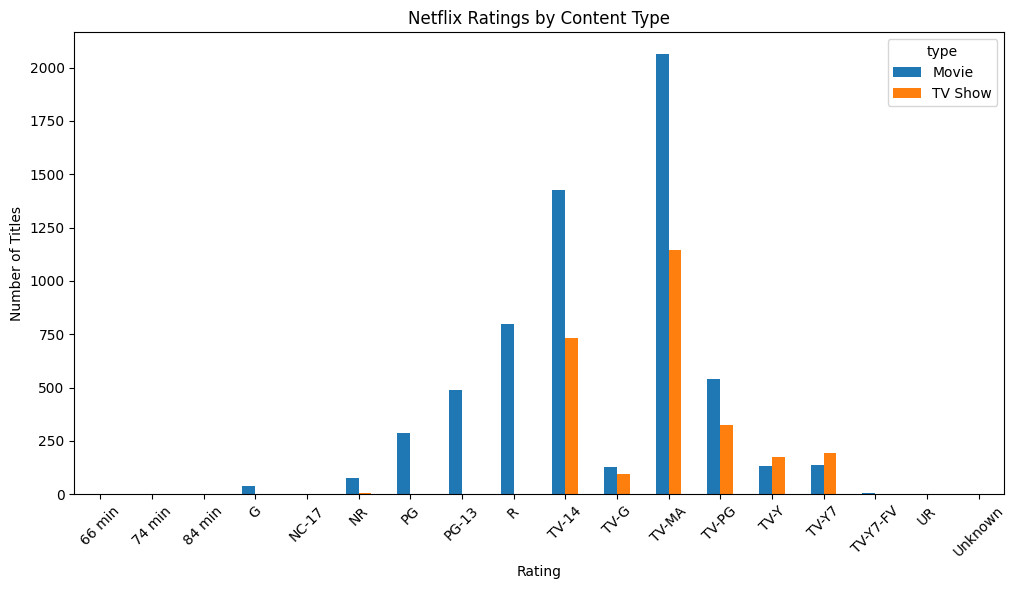

In [ ]:
#same as the above plot
rating_type.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Netflix Ratings by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

What percentage of Movies fall into each rating?-----------------------------------------

<Axes: xlabel='type'>

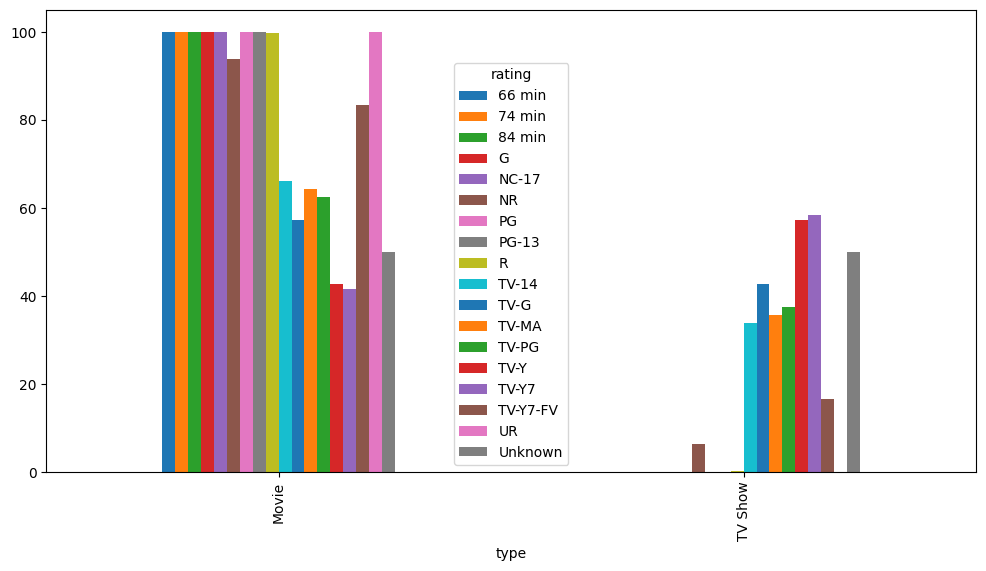

In [ ]:
rating_type_percentage = pd.crosstab(df_clean['rating'],df_clean['type'],normalize='index')*100
rating_type_percentage

rating_type_percentage.T.plot(kind='bar',figsize=(12,6))

Which ratings are most common within Movies?-------------------------------

In [ ]:
movie_rating = df_clean[df_clean['type']=='Movie']['rating'].value_counts(normalize=True)*100
movie_rating.head(5)



rating
TV-MA    33.632360
TV-14    23.275159
R        12.999511
TV-PG     8.807699
PG-13     7.992171
Name: proportion, dtype: float64

In [ ]:
tv_show_rating = df_clean[df_clean['type']=='TV Show']['rating'].value_counts(normalize=True)*100
tv_show_rating.head(3)

rating
TV-MA    42.787743
TV-14    27.391629
TV-PG    12.070254
Name: proportion, dtype: float64

Are ratings changing over time?---------------------------------------

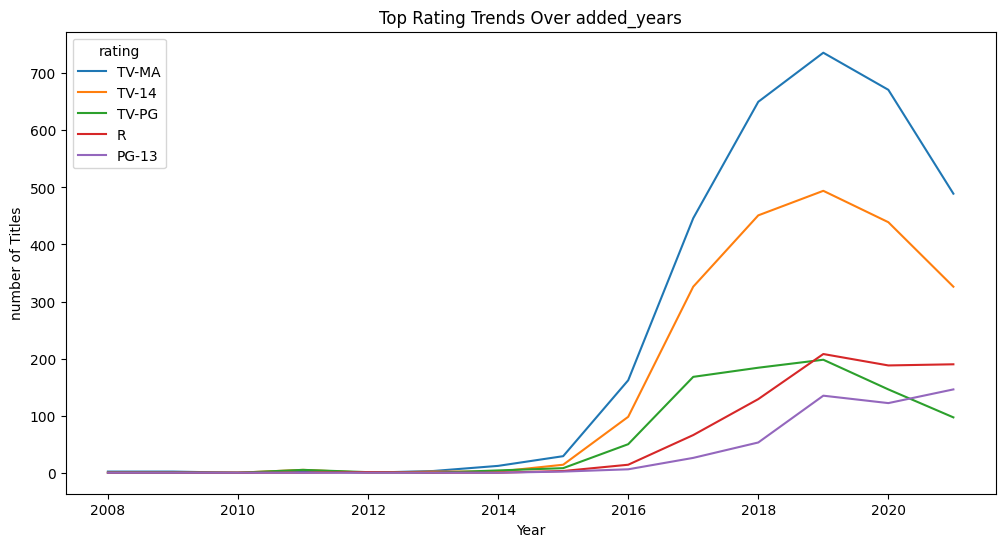

In [ ]:
rating_year = pd.crosstab(df_clean['added_year'],df_clean['rating'])
rating_year


top_ratings = df_clean['rating'].value_counts().head(5).index

rating_trend = rating_year[top_ratings]
rating_trend

rating_trend.plot(kind='line',figsize=(12,6))

plt.title('Top Rating Trends Over added_years')
plt.xlabel('Year')
plt.ylabel('number of Titles')
plt.show()

Step 10 — Director & Actor Analysis=============================================================================

Which directors are associated with the largest number of Netflix titles?--------------------------------------------

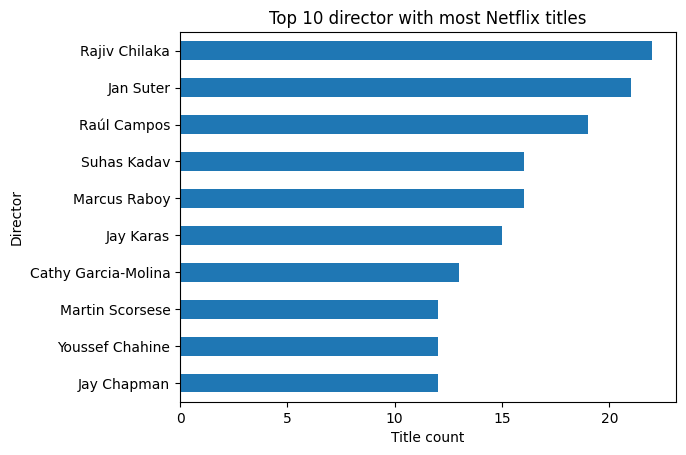

In [ ]:
director_count = title_director['director'].value_counts().head(10)

director_count.sort_values().plot(kind='barh')
plt.title('Top 10 director with most Netflix titles')
plt.xlabel('Title count')
plt.ylabel('Director')
plt.show()

In [ ]:
#No duplicates found
title_director.duplicated(subset=['show_id','director']).sum()

0

Are the top directors primarily associated with Movies or TV Shows?--------------------------------------------------

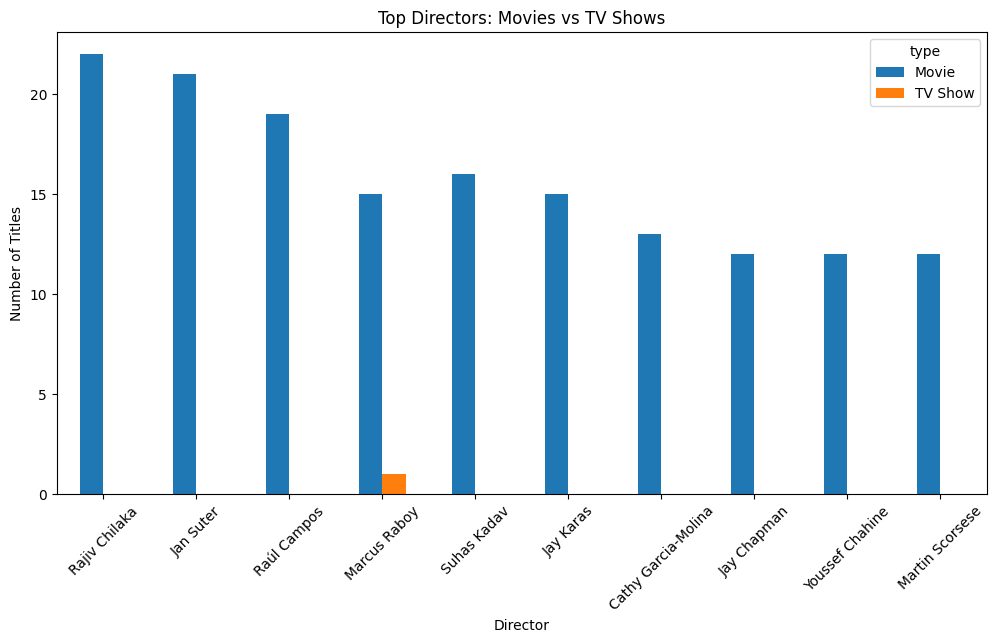

In [ ]:
director_type = title_director.merge(df_clean[['show_id','type']],on='show_id',how='left')
director_type.head()

director_type_table  = pd.crosstab(director_type['director'],director_type['type'])
top_directors = director_count.head(10).index
top_directors

director_type_table.loc[top_directors].plot(kind='bar',figsize=(12,6))

plt.title('Top Directors: Movies vs TV Shows')
plt.xlabel('Director')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

Which actors appear in the largest number of Netflix titles?-----------------------------------------------

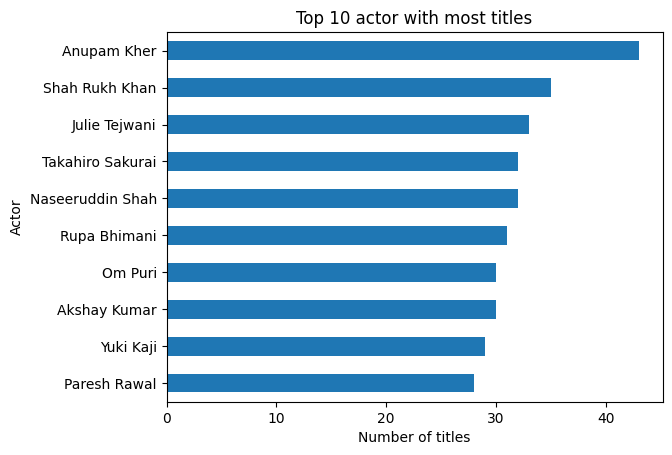

In [ ]:
actor_count = title_cast['cast_member'].value_counts().head(10)
actor_count.sort_values().plot(kind='barh')

plt.title('Top 10 actor with most titles')
plt.xlabel('Number of titles')
plt.ylabel('Actor')
plt.show()

In [ ]:
title_cast.duplicated(subset=['show_id','cast_member']).sum()

0

Are the top actors primarily associated with Movies or TV Shows?----------------------------------------------------

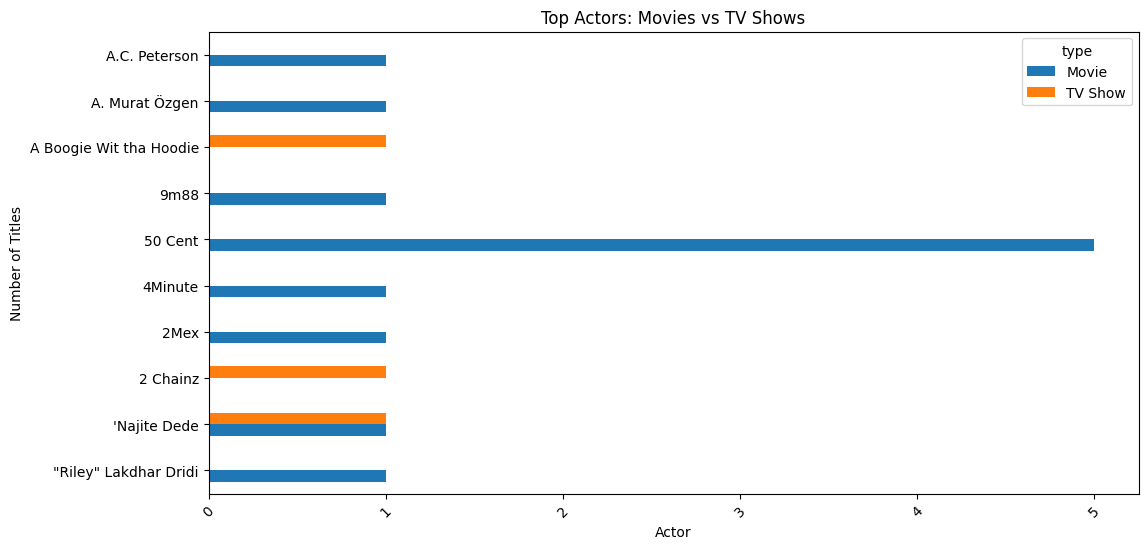

In [ ]:
actor_type = title_cast.merge(df_clean[['show_id','type']],on='show_id',how='left')
actor_type

actor_type_table = pd.crosstab(actor_type['cast_member'],actor_type['type'])
top_actors = actor_count.head(10).index

actor_type_table.loc[top_actors].plot(kind='barh',figsize=(12,6))
plt.title('Top Actors: Movies vs TV Shows')
plt.xlabel('Actor')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.show()

Which actors have worked across both Movies and TV Shows?-------------------------------------------------------

In [ ]:
actor_type_table.head()

type,Movie,TV Show
cast_member,,
"""Riley"" Lakdhar Dridi",1,0
'Najite Dede,1,1
2 Chainz,0,1
2Mex,1,0
4Minute,1,0


In [ ]:
actor_both = actor_type_table[(actor_type_table['Movie']>0) & (actor_type_table['TV Show']>0)]
actor_both.sort_values(by=['Movie','TV Show'],ascending=False).head(10)

type,Movie,TV Show
cast_member,,
Anupam Kher,42,1
Julie Tejwani,28,5
Rupa Bhimani,27,4
Samuel L. Jackson,22,2
Rajesh Kava,21,5
Kay Kay Menon,20,1
Nawazuddin Siddiqui,20,1
Nicolas Cage,20,1
John Cleese,19,5


Which countries are associated with the directors contributing the most titles?------------------------------------------

In [ ]:
director_country = title_director.merge(title_country[['show_id','country']],on='show_id',how='left')
director_country.head()

,show_id,title,director,country
0,s1,Dick Johnson Is Dead,Kirsten Johnson,United States
1,s3,Ganglands,Julien Leclercq,NaN
2,s6,Midnight Mass,Mike Flanagan,NaN
3,s7,My Little Pony: A New Generation,Robert Cullen,NaN
4,s7,My Little Pony: A New Generation,José Luis Ucha,NaN


In [ ]:
director_country.groupby(['director','country']).size().sort_values(ascending=False).head(20)

director             country      
Jay Karas            United States    15
Marcus Raboy         United States    15
Cathy Garcia-Molina  Philippines      13
Jay Chapman          United States    12
Youssef Chahine      Egypt            12
Martin Scorsese      United States    12
Jan Suter            Mexico           12
Steven Spielberg     United States    11
Raúl Campos          Mexico           10
Don Michael Paul     United States    10
Shannon Hartman      United States     9
David Dhawan         India             9
Yılmaz Erdoğan       Turkey            9
Anurag Kashyap       India             9
Troy Miller          United States     8
Hakan Algül          Turkey            8
Justin G. Dyck       Canada            8
Umesh Mehra          India             8
Hanung Bramantyo     Indonesia         8
Ryan Polito          United States     8
dtype: int64

In [ ]:
director_count.head(10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: count, dtype: int64

In [ ]:
actor_count.head(10)

cast_member
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

Step 11 — Duration Analysis=======================================================================================

In [ ]:
df_clean[['duration','movie_duration_min','tv_seasons']].head()

,duration,movie_duration_min,tv_seasons
0,90 min,90.0,NaN
1,2 Seasons,NaN,2.0
2,1 Season,NaN,1.0
3,1 Season,NaN,1.0
4,2 Seasons,NaN,2.0


What is the typical Movie runtime?------------------------------------------------------------

In [ ]:
df_clean['movie_duration_min'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: movie_duration_min, dtype: float64

In [ ]:
movie_mean = df_clean['movie_duration_min'].mean()
movie_median = df_clean['movie_duration_min'].median()

print(movie_mean,movie_median)
#the typical movie runtime is between 98-99 mins
#if mean=110 and median=95, for this skewed data we use the median

99.57718668407311 98.0


What does the Movie duration distribution look like?--------------------------------------------------

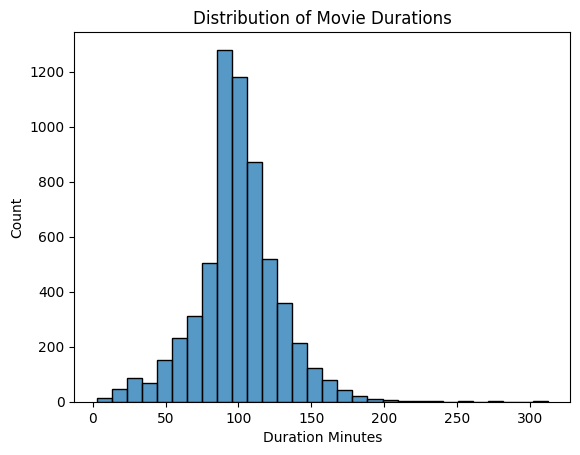

In [ ]:
sns.histplot(data=df_clean,x='movie_duration_min',bins=30)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration Minutes')
plt.show()
#as the data is slightly skewed to the right we are using boxplot to see the outlier

<Axes: ylabel='movie_duration_min'>

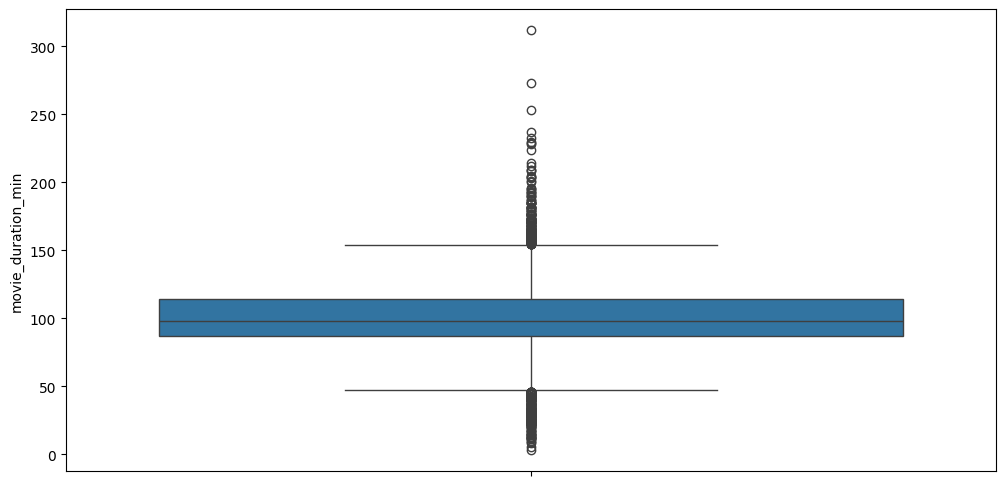

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(df_clean['movie_duration_min'])

#after finding outlier we should check like this


Find outlier
     ↓
Inspect the record
     ↓
Understand why it is extreme
     ↓
Is it an error?
   ↙       ↘
 Yes       No
 ↓          ↓
Correct/   Keep it
remove     and report
     ↓
Re-check analysis

Which Movie duration range is most common?----------------------------------------------------------------

Text(0.5, 1.0, 'Movie duration catgories')

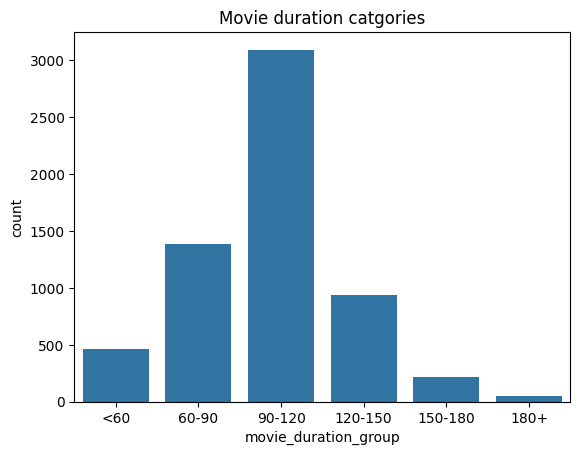

In [ ]:
bins=[0,60,90,120,150,180,2000]
labels=['<60','60-90','90-120','120-150','150-180','180+']

df_clean['movie_duration_group'] = pd.cut(df_clean['movie_duration_min'],bins=bins,labels=labels,right=False)
#right=False [60,90) 90 goes to the next bin[90,120)
#rifht=True  [60,90) 90 goes into the same bin[60,90)
df_clean['movie_duration_group'].value_counts().index

sns.countplot(data=df_clean,x='movie_duration_group')
plt.title('Movie duration catgories')

How many seasons do Netflix TV Shows typically have?---------------------------------------------------

In [ ]:
df_clean.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,director_list,cast_list,country_list,genre_list,added_year,added_month,added_month_name,movie_duration_min,tv_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",[Kirsten Johnson],[Unknown],[United States],[Documentaries],2021.0,9.0,September,90.0,NaN
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,"After crossing paths at a party, a Cape Town t...",[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,9.0,September,NaN,2.0


In [ ]:
nona_season = df_clean[df_clean['tv_seasons'].notna()]

In [ ]:
nona_season['tv_seasons'].describe()

count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: tv_seasons, dtype: float64

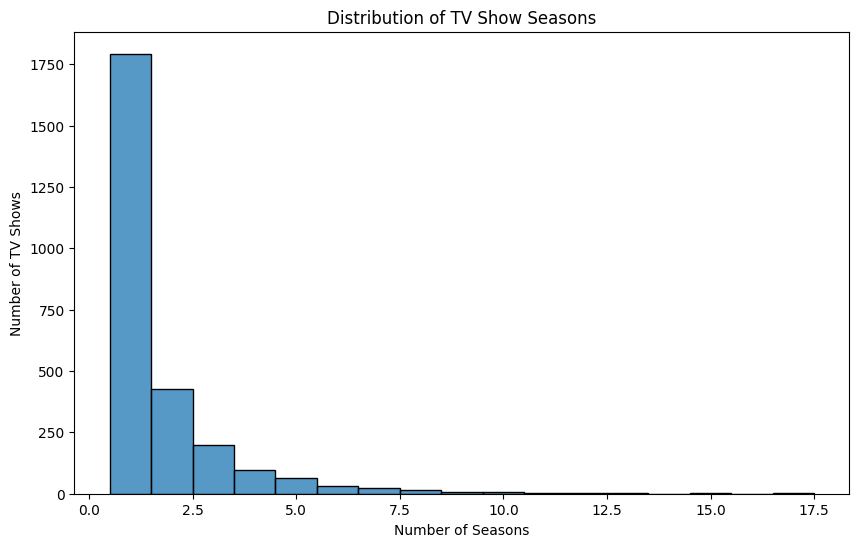

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=nona_season,
    x='tv_seasons',
    discrete=True
)

#data is right skewed
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')

plt.show()

How many TV Shows are single-season?---------------------------------------------------------------

In [ ]:
single_season = nona_season[nona_season['tv_seasons']==1.0]
single_season['tv_seasons'].shape[0]

1793

In [ ]:
single_season_percentage = ((df_clean['tv_seasons'] == 1).sum() / df_clean['tv_seasons'].notna().sum()* 100)

print(single_season_percentage)

67.00298953662183


duration by release year------------------------------------------------

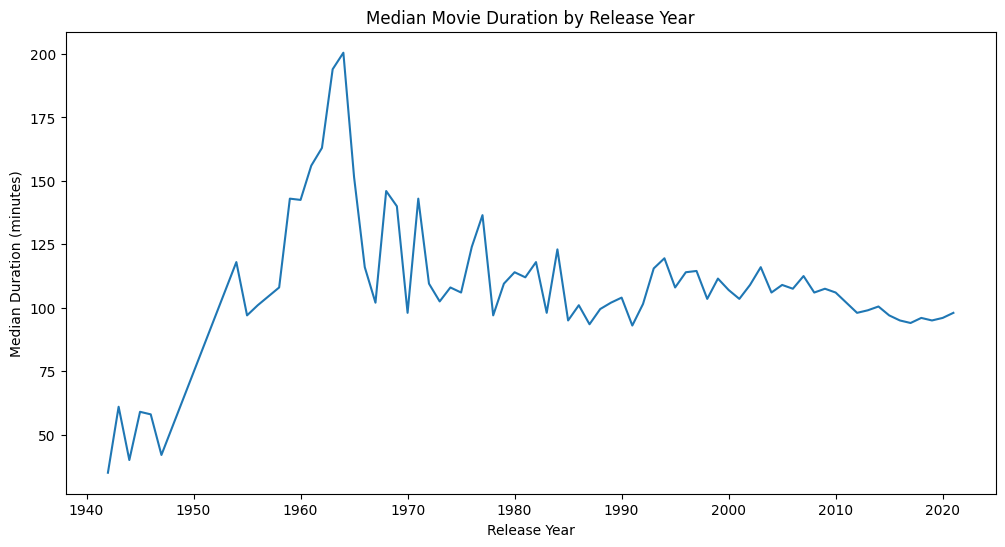

In [ ]:
movie_duration_year = df_clean[df_clean['type']=='Movie'].groupby('release_year')['movie_duration_min'].median()
movie_duration_year

movie_duration_year.plot(
    figsize=(12, 6)
)

plt.title('Median Movie Duration by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Median Duration (minutes)')

plt.show()

Step 12 — Release Year & Content Growth Analysis===================================================

What is the distribution of content by release year?----------------------------------------------------

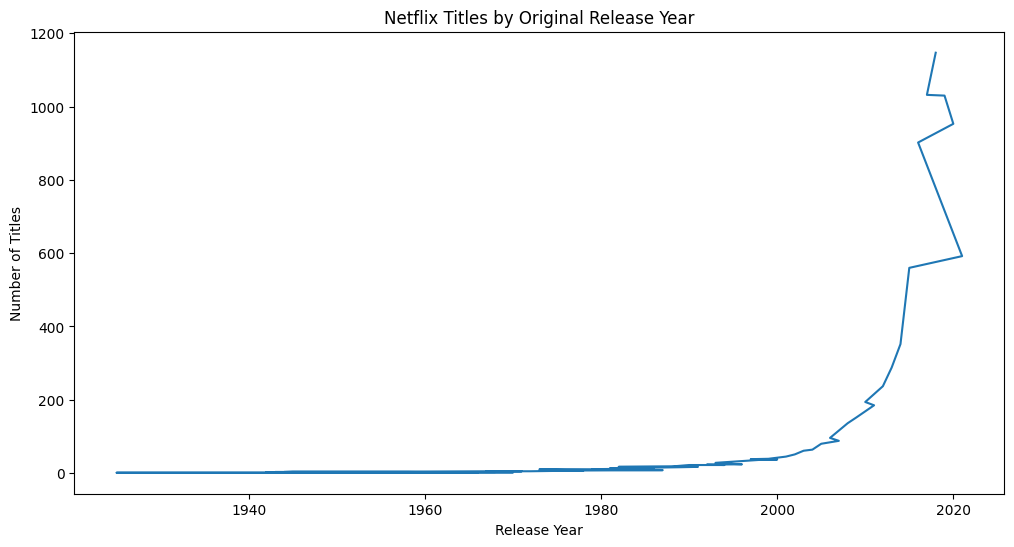

In [ ]:
release_year_count = df_clean['release_year'].value_counts()
release_year_count

plt.figure(figsize=(12, 6))

release_year_count.plot(kind='line')

plt.title('Netflix Titles by Original Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

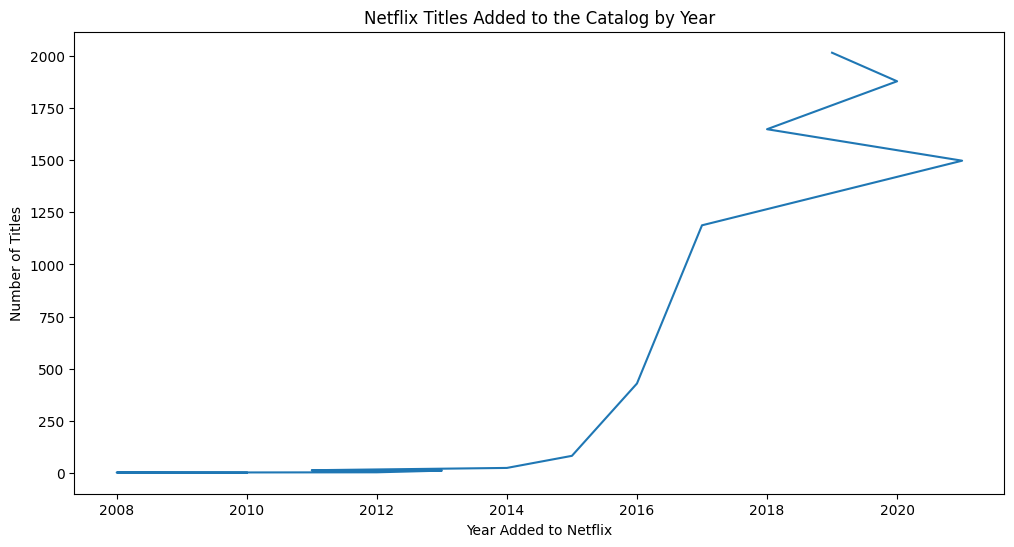

In [ ]:
added_year_count = (df_clean['added_year'].value_counts())

plt.figure(figsize=(12, 6))

added_year_count.plot(kind='line')

plt.title('Netflix Titles Added to Netflix by Year')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles')

plt.show()

In [ ]:
peak_year = added_year_count.idxmax()
peak_count = added_year_count.max()

print(
    f"Peak catalog additions occurred in {peak_year} "
    f"with {peak_count} titles."
)

Peak catalog additions occurred in 2019.0 with 2016 titles.


In [ ]:
df_clean['content_age_when_added'] = (df_clean['added_year'] -df_clean['release_year'])

df_clean['content_age_when_added'].describe()

count    8797.000000
mean        4.688417
std         8.786998
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age_when_added, dtype: float64

Were Movies or TV Shows driving Netflix growth?----------------------------------------------

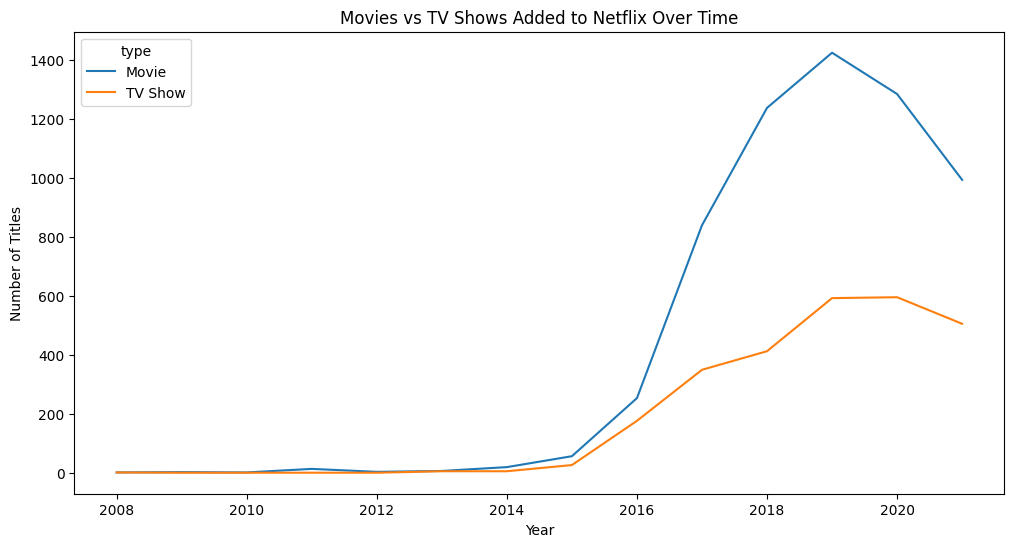

In [ ]:
content_growth = pd.crosstab(df_clean['added_year'],df_clean['type'])
content_growth


content_growth.plot(kind='line',figsize=(12,6))

plt.title('Movies vs TV Shows Added to Netflix Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

What proportion of new additions are Movies vs TV Shows?---------------------------------------------------

Text(0, 0.5, 'Percentage')

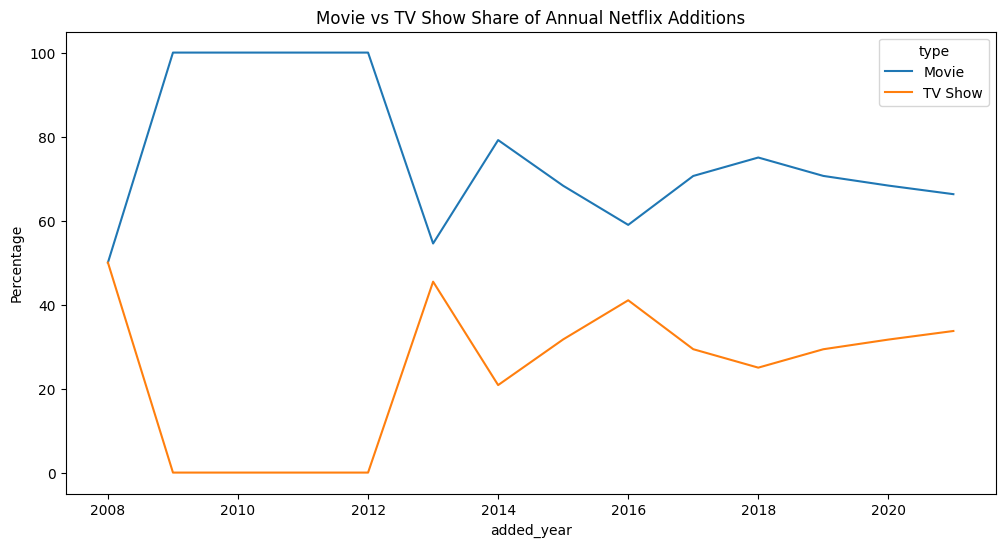

In [ ]:
content_growth_pct = pd.crosstab(df_clean['added_year'],df_clean['type'],normalize='index')*100
content_growth_pct

content_growth_pct.plot(kind='line',figsize=(12,6))

plt.title('Movie vs TV Show Share of Annual Netflix Additions')
plt.ylabel('Percentage')

Is Netflix adding newer content?--------------------------------------------------------

In [ ]:
df_clean['content_age_when_added'] = (df_clean['added_year'] - df_clean['release_year'])
#Content added lesser than or equal to 5 years from the sub of added year and release year
df_clean['content_age_when_added'][df_clean['content_age_when_added'] <= 5.0].shape[0]

6673

In [ ]:
df_clean['content_age_when_added'].describe()

count    8797.000000
mean        4.688417
std         8.786998
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age_when_added, dtype: float64

Is Netflix adding newer or older content?------------------------------------------------

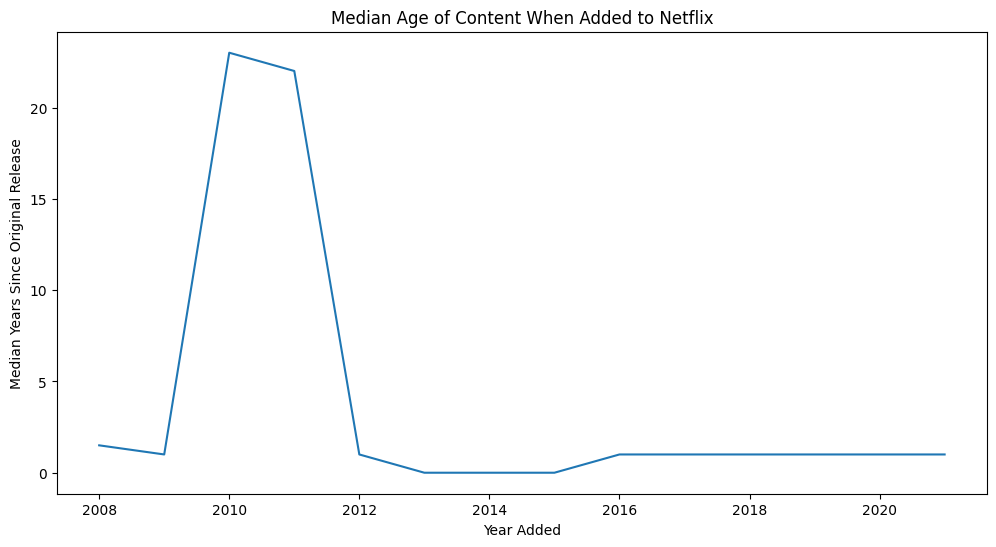

In [ ]:
content_age_trend = (df_clean.groupby('added_year')['content_age_when_added'].median())
content_age_trend

content_age_trend.plot(
    figsize=(12, 6)
)

plt.title('Median Age of Content When Added to Netflix')
plt.xlabel('Year Added')
plt.ylabel('Median Years Since Original Release')

plt.show()

In [ ]:
(df_clean['content_age_when_added'] < 0).sum()

df_clean[
    df_clean['content_age_when_added'] < 0
][[
    'title',
    'release_year',
    'added_year',
    'content_age_when_added'
]]

,title,release_year,added_year,content_age_when_added
1551,Hilda,2021,2020.0,-1.0
1696,Polly Pocket,2021,2020.0,-1.0
2920,Love Is Blind,2021,2020.0,-1.0
3168,Fuller House,2020,2019.0,-1.0
3287,Maradona in Mexico,2020,2019.0,-1.0
3369,BoJack Horseman,2020,2019.0,-1.0
3433,The Hook Up Plan,2020,2019.0,-1.0
4844,Unbreakable Kimmy Schmidt,2019,2018.0,-1.0
4845,Arrested Development,2019,2018.0,-1.0
5394,Hans Teeuwen: Real Rancour,2018,2017.0,-1.0


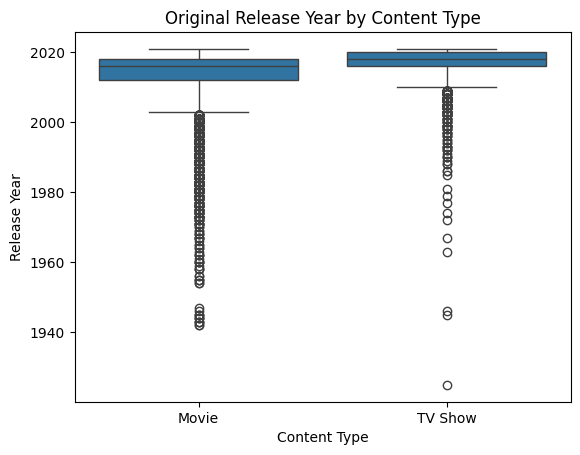

In [ ]:
release_type = (df_clean.groupby('type')['release_year'].median())
release_type

sns.boxplot(data=df_clean,x='type',y='release_year')

plt.title('Original Release Year by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Release Year')

plt.show()

Step 13 — Cross-Dimensional Analysis========================================================================

13.1 Country × Content Type-----------------------------

In [ ]:
top5_countries = (
    title_country['country']
    .value_counts()
    .head(5)
    .index
)

top5_genres = (
    title_genre['genre']
    .value_counts()
    .head(5)
    .index
)

In [ ]:
country_genre = title_country.merge(
    title_genre[['show_id', 'genre']],
    on='show_id',
    how='inner'
)

cg = country_genre[country_genre['country'].isin(top5_countries) & country_genre['genre'].isin(top5_genres)]

country_genre_table = pd.crosstab(cg['country'],cg['genre'])
country_genre_table

genre,Comedies,Documentaries,Dramas,International Movies,International TV Shows
country,,,,,
Canada,94,42,82,60,25
France,51,44,167,207,43
India,323,27,662,864,66
United Kingdom,91,128,197,170,128
United States,680,512,835,166,74


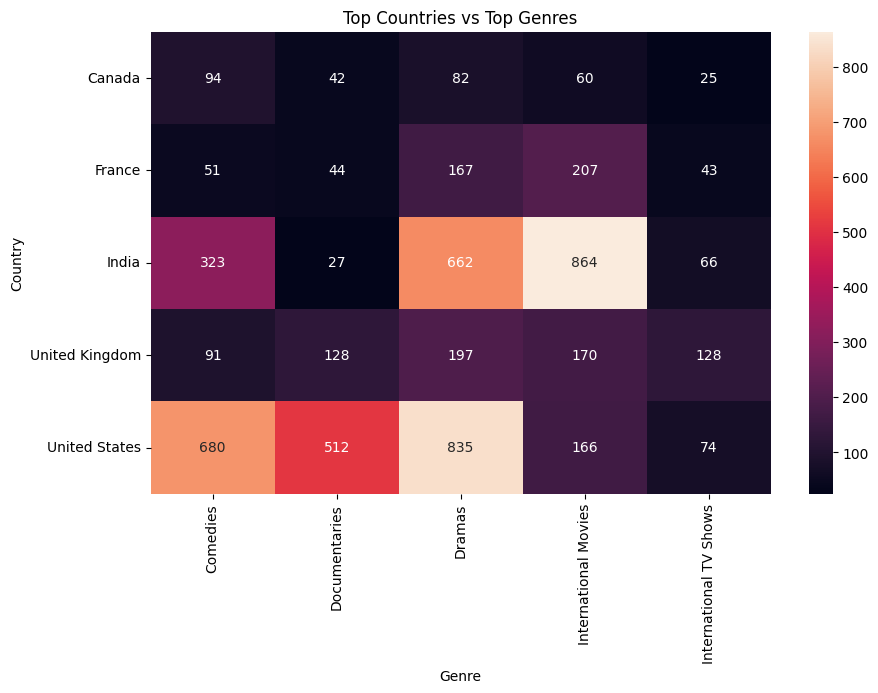

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    country_genre_table,
    annot=True,
    fmt='d'
)

plt.title('Top Countries vs Top Genres')
plt.xlabel('Genre')
plt.ylabel('Country')

plt.show()

Step 14 — Advanced Insights & Business Recommendations========================================================

Calculate concentration
How dependent is the catalog on the top countries?------------------------------

In [ ]:
country_count = title_country['country'].value_counts()

top5_country_share = (country_count.head(5).sum()/country_count.sum()*100)
top5_country_share

63.67900988122567

In [ ]:
genre_counts = title_genre['genre'].value_counts()

top5_genre_share = (genre_counts.head(5).sum() /genre_counts.sum()
    * 100
)

print(top5_genre_share)

46.95440666563163


In [ ]:
recent = df_clean[df_clean['added_year'] >= 2020]
recent_mix = recent['type'].value_counts(normalize=True)*100

overall_mix = df_clean['type'].value_counts(normalize=True)*100

comparison = pd.DataFrame({'Overall Catalog %': overall_mix,'Recent Additions %': recent_mix})
comparison

,Overall Catalog %,Recent Additions %
type,,
Movie,69.615079,67.42671
TV Show,30.384921,32.57329


Step 15 — Final EDA Audit & Quality Review===========================================================

In [328]:
print("Director duplicates:",
      title_director.duplicated(['show_id', 'director']).sum())

print("Cast duplicates:",
      title_cast.duplicated(['show_id', 'cast_member']).sum())

print("Country duplicates:",
      title_country.duplicated(['show_id', 'country']).sum())

print("Genre duplicates:",
      title_genre.duplicated(['show_id', 'genre']).sum())

Director duplicates: 0
Cast duplicates: 0
Country duplicates: 0
Genre duplicates: 0


In [329]:
print("Main titles:", len(df_clean))
print("Title-director relationships:", len(title_director))
print("Title-cast relationships:", len(title_cast))
print("Title-country relationships:", len(title_country))
print("Title-genre relationships:", len(title_genre))

Main titles: 8807
Title-director relationships: 6977
Title-cast relationships: 64124
Title-country relationships: 10019
Title-genre relationships: 19323


In [331]:
print("Titles with directors:",
      title_director['show_id'].nunique())

print("Titles with cast:",
      title_cast['show_id'].nunique())

print("Titles with countries:",
      title_country['show_id'].nunique())

print("Titles with genres:",
      title_genre['show_id'].nunique())

Titles with directors: 6173
Titles with cast: 7982
Titles with countries: 7976
Titles with genres: 8807


In [332]:
df_clean['show_id'].nunique()

8807

In [333]:
df_clean['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [335]:
df_clean.loc[
    df_clean['type'] == 'Movie',
    'tv_seasons'
].notna().sum()

df_clean.loc[
    df_clean['type'] == 'TV Show',
    'movie_duration_min'
].notna().sum()

0

In [336]:
df_clean['rating'].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [338]:
df_clean.loc[df_clean['rating'].str.contains('min', na=False),'rating'] = 'Unknown'
df_clean['rating'].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64